# 🏭 Steel Plates Faults Prediction — IDSS Final Project
### AIS431 - Intelligent Decision Support Systems | Dr. Nehal Ali

---

## 📋 Project Description
This project develops an **Intelligent Decision Support System (IDSS)** for a steel
manufacturing facility. The system automatically detects and classifies surface defects
in steel plates using machine learning, enabling real-time quality control decisions
that reduce scrap, minimize manual inspection costs, and improve production yield.

---

## 📦 Dataset
| | |
|---|---|
| **Source** | UCI Machine Learning Repository — Steel Plates Faults (ID: 198) |
| **Samples** | 1,941 steel plate records |
| **Features** | 27 numerical measurements (spatial, luminosity, material, image indices) |
| **Targets** | 7 mutually exclusive defect classes |
| **Task** | Multi-class Classification |
| **Metric** | Multi-class AUC (one-vs-rest, averaged across 7 classes) |

**7 Defect Types:** `Pastry` · `Z_Scratch` · `K_Scratch` · `Stains` · `Dirtiness` · `Bumps` · `Other_Faults`

---

## 🎯 Problem Statement
A steel production facility needs to automate surface defect detection to replace
slow and error-prone manual inspection. Given 27 physical measurements extracted
from imaging systems, the goal is to predict **which single defect type** is present
on each steel plate. Each plate belongs to exactly one of 7 defect categories.

> 📌 **EDA Finding:** Although the dataset is structured with 7 binary target columns,
> verification confirmed every plate has exactly 1 active label — making this a
> **multi-class classification** problem, not multi-label.

**Key Challenge:** Severe class imbalance across defect types
(Dirtiness: 2.8% vs Other_Faults: 34.7%) requires careful model design
and evaluation using AUC rather than accuracy.

In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----- LOAD DATASET -----
steel_plates_faults = fetch_ucirepo(id=198)

X = steel_plates_faults.data.features   # 27 features
y = steel_plates_faults.data.targets    # 7 defect labels

# Combine into one DataFrame for EDA
df = pd.concat([X, y], axis=1)

print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape}")

✅ Dataset loaded successfully!
Shape: (1941, 34)


In [3]:
# ----- INITIAL INSPECTION -----

print("=== FEATURES (X) ===")
print(X.shape)
print(X.dtypes)

print("\n=== TARGETS (y) ===")
print(y.shape)
print(y.columns.tolist())

print("\n=== METADATA ===")
print(steel_plates_faults.metadata.abstract)
print("Missing values:", steel_plates_faults.metadata.has_missing_values)

print("\n=== VARIABLE INFO ===")
print(steel_plates_faults.variables)

=== FEATURES (X) ===
(1941, 27)
X_Minimum                  int64
X_Maximum                  int64
Y_Minimum                  int64
Y_Maximum                  int64
Pixels_Areas               int64
X_Perimeter                int64
Y_Perimeter                int64
Sum_of_Luminosity          int64
Maximum_of_Luminosity      int64
Length_of_Conveyer         int64
TypeOfSteel_A300           int64
TypeOfSteel_A400           int64
Steel_Plate_Thickness      int64
Edges_Index              float64
Empty_Index              float64
Square_Index             float64
Outside_X_Index          float64
Edges_X_Index            float64
Edges_Y_Index            float64
Outside_Global_Index     float64
LogOfAreas               float64
Log_X_Index              float64
Log_Y_Index              float64
Orientation_Index        float64
Luminosity_Index         float64
SigmoidOfAreas           float64
Minimum_of_Luminosity      int64
dtype: object

=== TARGETS (y) ===
(1941, 7)
['Pastry', 'Z_Scratch', 'K_Scrat

In [12]:
# ----- DATA TYPES & MEMORY USAGE -----

print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MEMORY USAGE ===")
memory = df.memory_usage(deep=True)
print(memory)
print(f"\nTotal Memory: {memory.sum() / 1024:.2f} KB")

=== DATA TYPES ===
X_Minimum                  int64
X_Maximum                  int64
Y_Minimum                  int64
Y_Maximum                  int64
Pixels_Areas               int64
X_Perimeter                int64
Y_Perimeter                int64
Sum_of_Luminosity          int64
Maximum_of_Luminosity      int64
Length_of_Conveyer         int64
TypeOfSteel_A300           int64
TypeOfSteel_A400           int64
Steel_Plate_Thickness      int64
Edges_Index              float64
Empty_Index              float64
Square_Index             float64
Outside_X_Index          float64
Edges_X_Index            float64
Edges_Y_Index            float64
Outside_Global_Index     float64
LogOfAreas               float64
Log_X_Index              float64
Log_Y_Index              float64
Orientation_Index        float64
Luminosity_Index         float64
SigmoidOfAreas           float64
Minimum_of_Luminosity      int64
Pastry                     int64
Z_Scratch                  int64
K_Scratch               

In [14]:
# ----- MISSING VALUES & BASIC STATS -----

print("=== MISSING VALUES ===")
print(df.isnull().sum().sum(), "total missing values")

print("\n=== DUPLICATES ===")
print(df.duplicated().sum(), "duplicate rows")

print("=== FEATURE STATISTICS ===")
display(X.describe().round(2))

print("\n=== TARGET STATISTICS ===")
display(y.describe().round(2))

=== MISSING VALUES ===
0 total missing values

=== DUPLICATES ===
0 duplicate rows
=== FEATURE STATISTICS ===


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Minimum_of_Luminosity
count,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,...,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00
mean,571.14,617.96,1650684.87,1650738.71,1893.88,111.86,82.97,206312.15,130.19,1459.16,...,0.61,0.81,0.58,2.49,1.34,1.40,0.08,-0.13,0.59,84.55
std,520.69,497.63,1774578.41,1774590.09,5168.46,301.21,426.48,512293.59,18.69,144.58,...,0.24,0.23,0.48,0.79,0.48,0.45,0.50,0.15,0.34,32.13
min,0.00,4.00,6712.00,6724.00,2.00,2.00,1.00,250.00,37.00,1227.00,...,0.01,0.05,0.00,0.30,0.30,0.00,-0.99,-1.00,0.12,0.00
25%,51.00,192.00,471253.00,471281.00,84.00,15.00,13.00,9522.00,124.00,1358.00,...,0.41,0.60,0.00,1.92,1.00,1.08,-0.33,-0.20,0.25,63.00
50%,435.00,467.00,1204128.00,1204136.00,174.00,26.00,25.00,19202.00,127.00,1364.00,...,0.64,0.95,1.00,2.24,1.18,1.32,0.10,-0.13,0.51,90.00
75%,1053.00,1072.00,2183073.00,2183084.00,822.00,84.00,83.00,83011.00,140.00,1650.00,...,0.80,1.00,1.00,2.91,1.52,1.73,0.51,-0.07,1.00,106.00
max,1705.00,1713.00,12987661.00,12987692.00,152655.00,10449.00,18152.00,11591414.00,253.00,1794.00,...,1.00,1.00,1.00,5.18,3.07,4.26,0.99,0.64,1.00,203.00



=== TARGET STATISTICS ===


,Pastry,Z_Scratch,K_Scratch,Stains,Dirtiness,Bumps,Other_Faults
count,1941.00,1941.0,1941.0,1941.00,1941.00,1941.00,1941.00
mean,0.08,0.1,0.2,0.04,0.03,0.21,0.35
std,0.27,0.3,0.4,0.19,0.17,0.41,0.48
min,0.00,0.0,0.0,0.00,0.00,0.00,0.00
25%,0.00,0.0,0.0,0.00,0.00,0.00,0.00
50%,0.00,0.0,0.0,0.00,0.00,0.00,0.00
75%,0.00,0.0,0.0,0.00,0.00,0.00,1.00
max,1.00,1.0,1.0,1.00,1.00,1.00,1.00


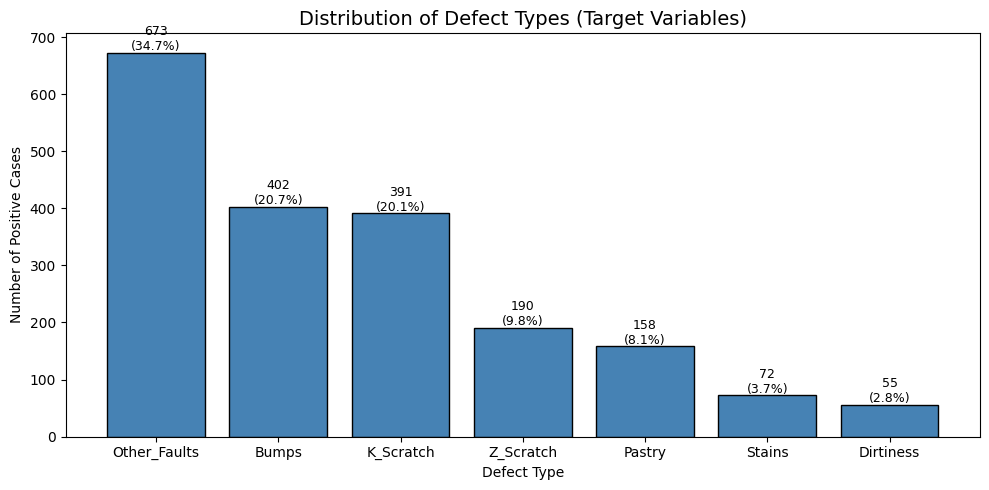

In [5]:
# ----- TARGET DISTRIBUTION (Class Imbalance Check) -----

target_cols = y.columns.tolist()
defect_counts = y.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(defect_counts.index, defect_counts.values, color='steelblue', edgecolor='black')
plt.title('Distribution of Defect Types (Target Variables)', fontsize=14)
plt.xlabel('Defect Type')
plt.ylabel('Number of Positive Cases')
for bar, val in zip(bars, defect_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val}\n({val/len(y)*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

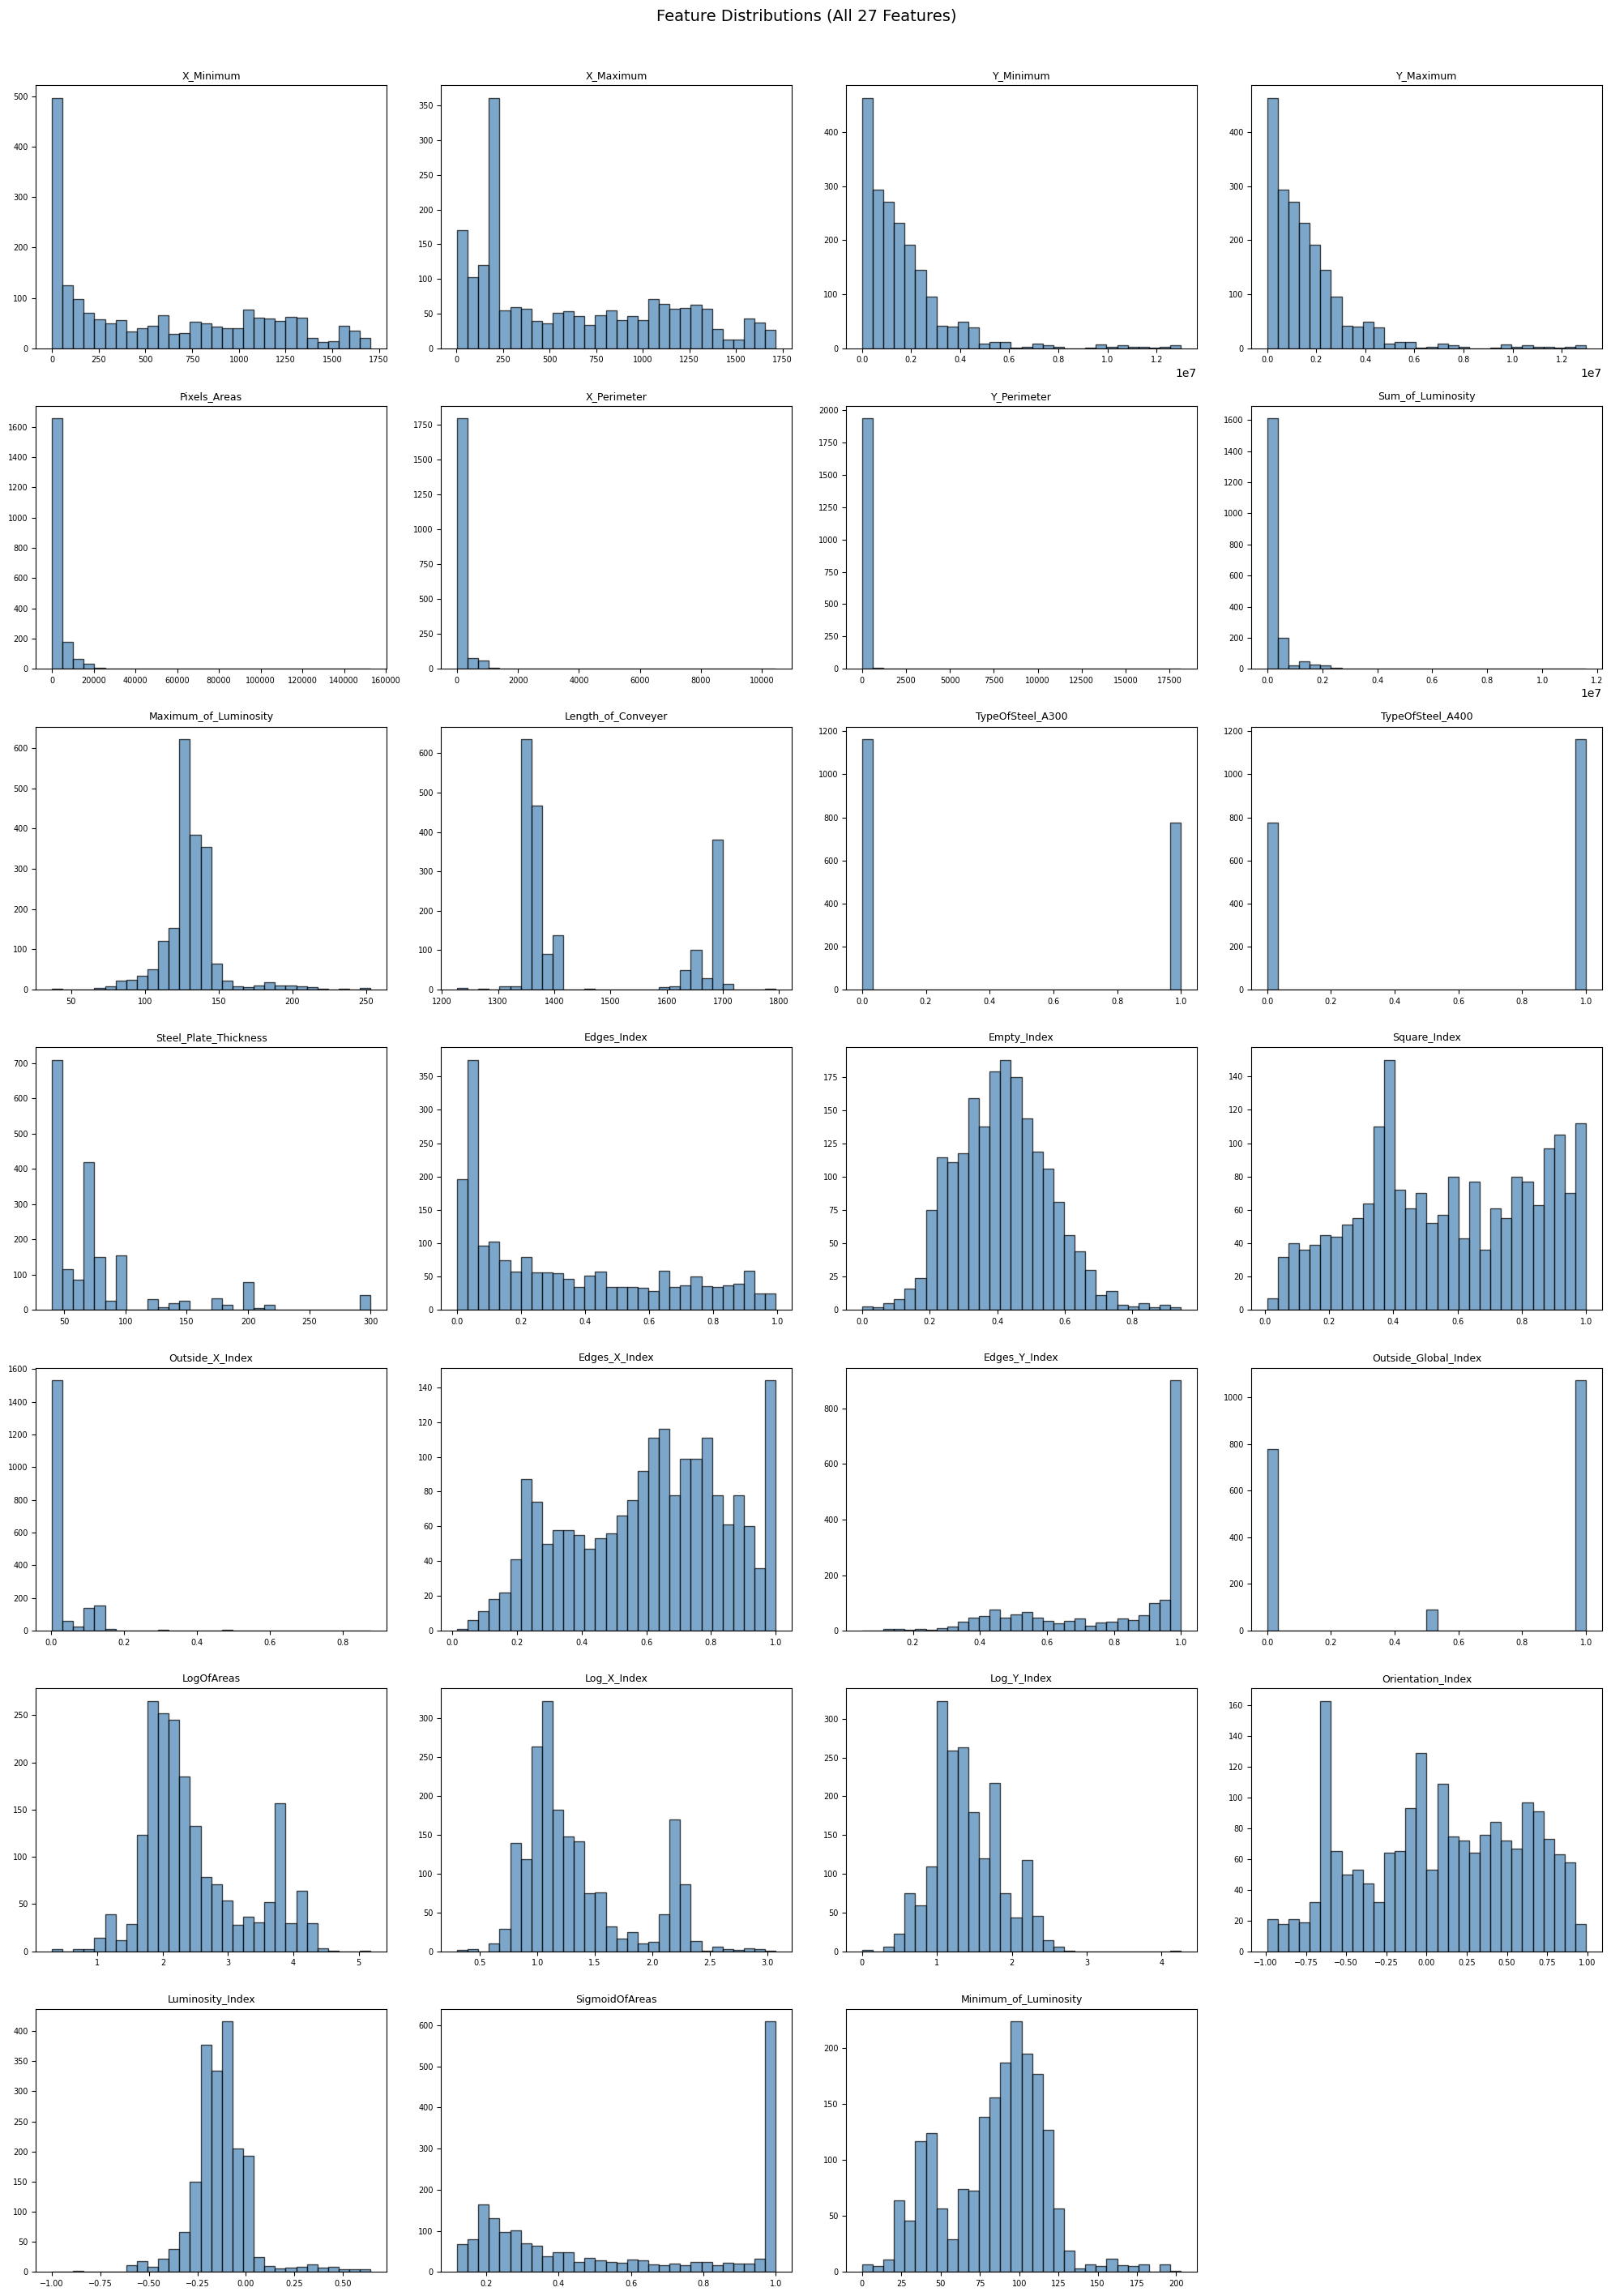

In [6]:
# ----- FEATURE DISTRIBUTIONS (Histograms) -----

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)

# Hide unused subplots (27 features, 28 slots)
axes[-1].set_visible(False)

plt.suptitle('Feature Distributions (All 27 Features)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

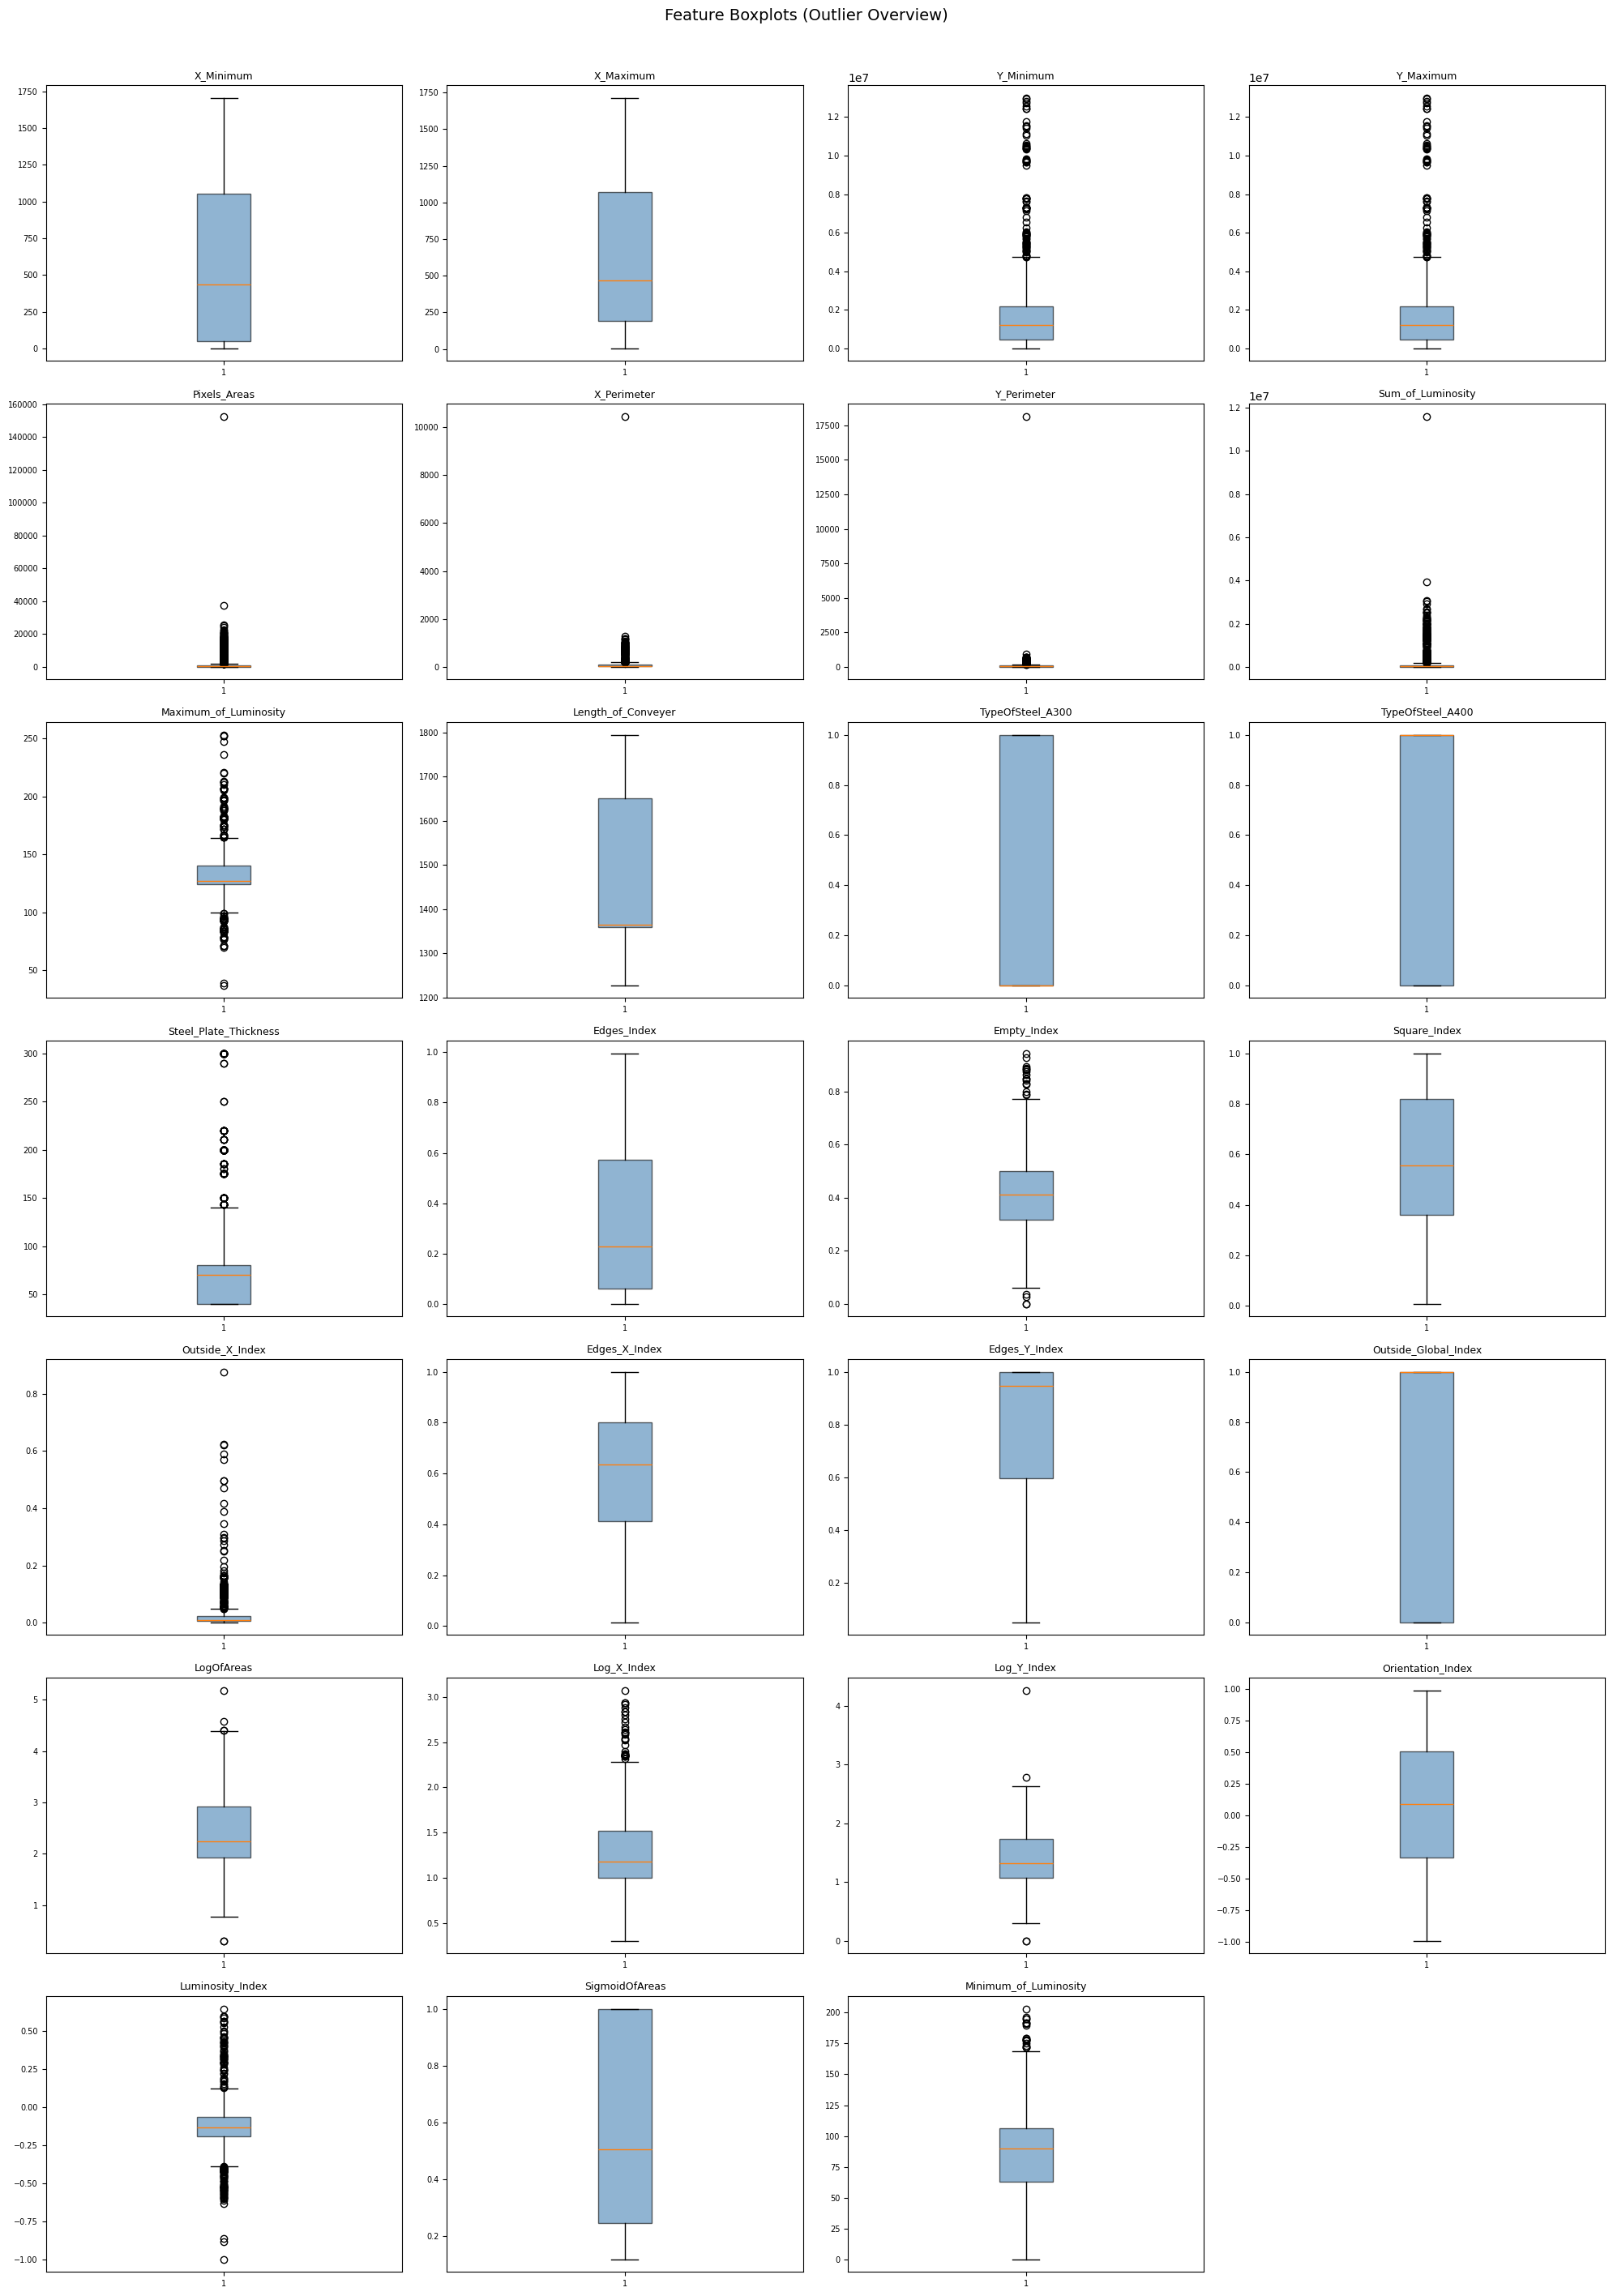

In [7]:
# ----- BOXPLOTS (Outlier Detection) -----

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].boxplot(X[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

axes[-1].set_visible(False)

plt.suptitle('Feature Boxplots (Outlier Overview)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_10438/2213838391.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([negative, positive], labels=['No', 'Yes'],
/tmp/ipykernel_10438/2213838391.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([negative, positive], labels=['No', 'Yes'],
/tmp/ipykernel_10438/2213838391.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([negative, positive], labels=['No', 'Yes'],
/tmp/ipykernel_10438/2213838391.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dro

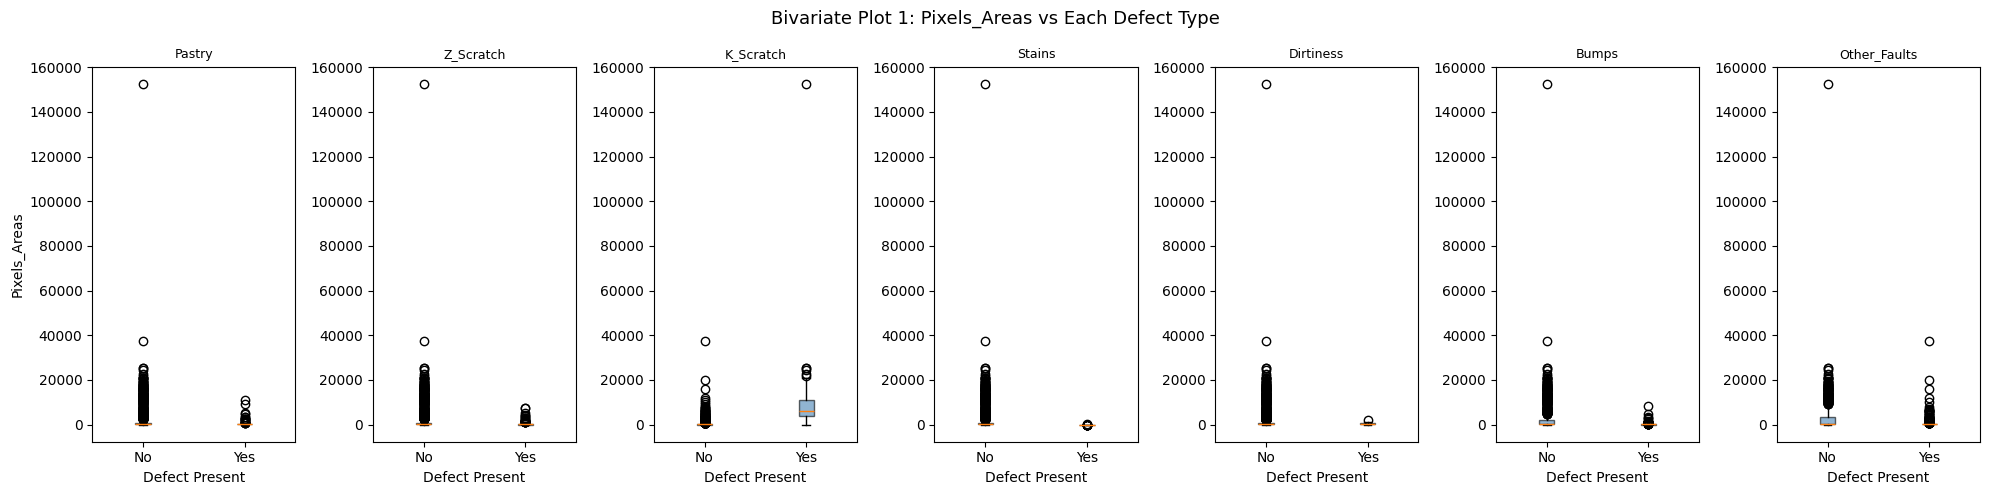

In [8]:
# ----- BIVARIATE PLOT 1: Pixels_Areas by Defect Type -----
# Business relevance: larger defects may signal specific fault types

fig, axes = plt.subplots(1, 7, figsize=(20, 5), sharey=False)

for i, defect in enumerate(target_cols):
    positive = X.loc[y[defect] == 1, 'Pixels_Areas']
    negative = X.loc[y[defect] == 0, 'Pixels_Areas']
    axes[i].boxplot([negative, positive], labels=['No', 'Yes'],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(defect, fontsize=9)
    axes[i].set_xlabel('Defect Present')

axes[0].set_ylabel('Pixels_Areas')
plt.suptitle('Bivariate Plot 1: Pixels_Areas vs Each Defect Type', fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_10438/1173878011.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([negative, positive], labels=['No', 'Yes'],
/tmp/ipykernel_10438/1173878011.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([negative, positive], labels=['No', 'Yes'],
/tmp/ipykernel_10438/1173878011.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([negative, positive], labels=['No', 'Yes'],
/tmp/ipykernel_10438/1173878011.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dro

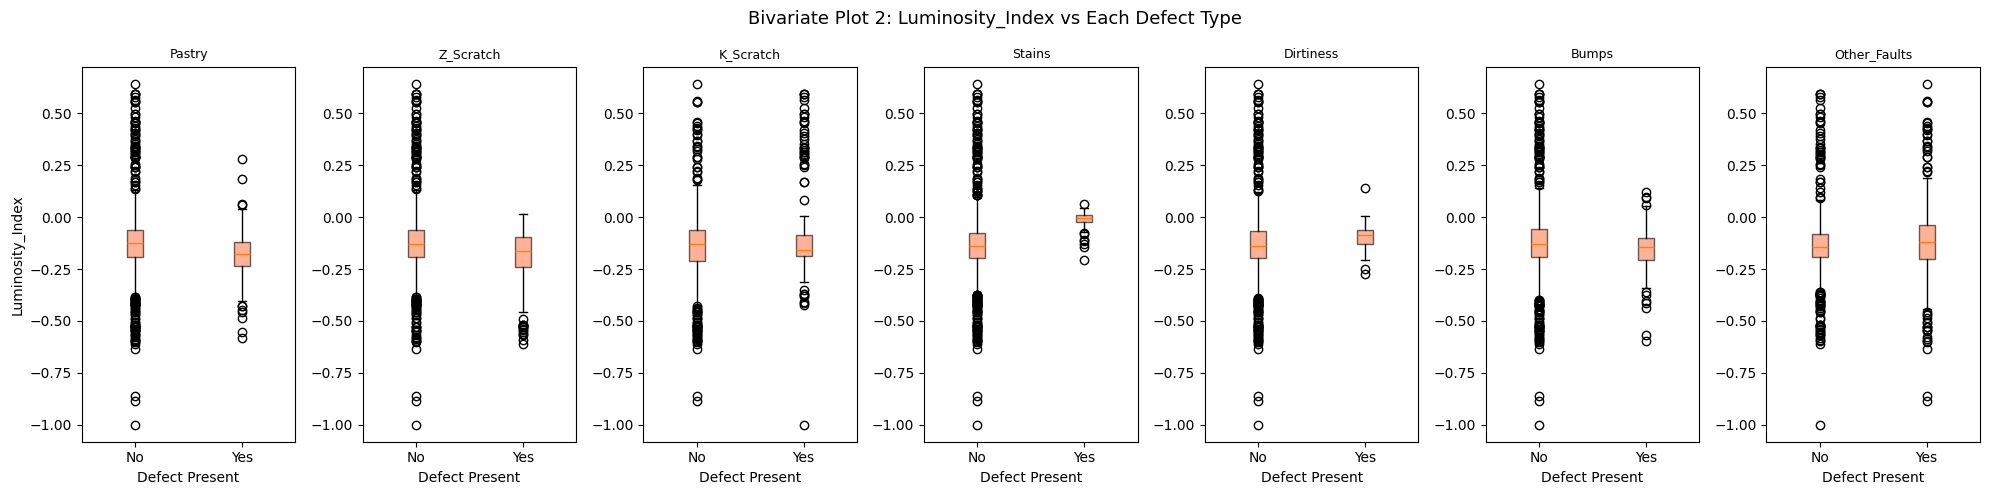

In [9]:
# ----- BIVARIATE PLOT 2: Luminosity Index by Defect Type -----
# Business relevance: brightness differences may distinguish surface defect types

fig, axes = plt.subplots(1, 7, figsize=(20, 5))

for i, defect in enumerate(target_cols):
    positive = X.loc[y[defect] == 1, 'Luminosity_Index']
    negative = X.loc[y[defect] == 0, 'Luminosity_Index']
    axes[i].boxplot([negative, positive], labels=['No', 'Yes'],
                    patch_artist=True,
                    boxprops=dict(facecolor='coral', alpha=0.6))
    axes[i].set_title(defect, fontsize=9)
    axes[i].set_xlabel('Defect Present')

axes[0].set_ylabel('Luminosity_Index')
plt.suptitle('Bivariate Plot 2: Luminosity_Index vs Each Defect Type', fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_10438/3375382914.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([negative, positive], labels=['No', 'Yes'],
/tmp/ipykernel_10438/3375382914.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([negative, positive], labels=['No', 'Yes'],
/tmp/ipykernel_10438/3375382914.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([negative, positive], labels=['No', 'Yes'],
/tmp/ipykernel_10438/3375382914.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dro

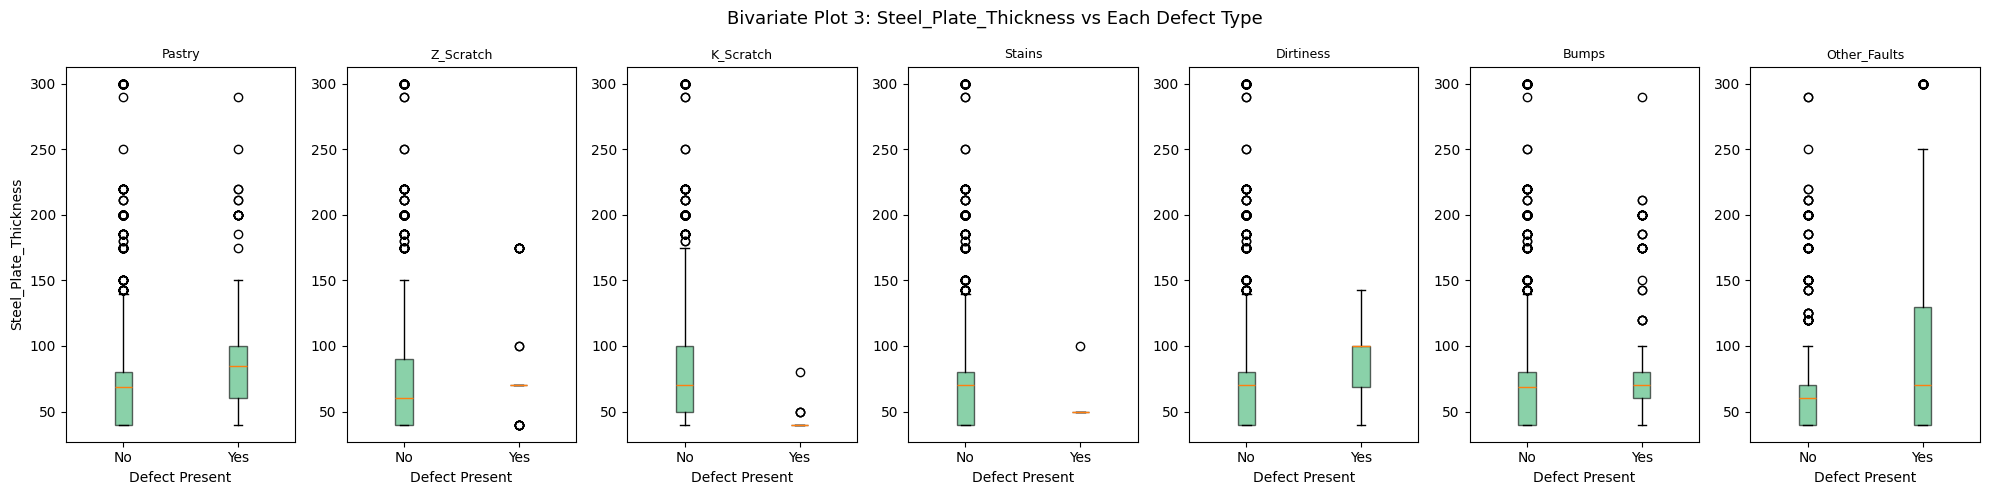

In [11]:
# ----- BIVARIATE PLOT 3: Steel Plate Thickness by Defect Type -----
# Business relevance: thicker plates may have different defect profiles

fig, axes = plt.subplots(1, 7, figsize=(20, 5))

for i, defect in enumerate(target_cols):
    positive = X.loc[y[defect] == 1, 'Steel_Plate_Thickness']
    negative = X.loc[y[defect] == 0, 'Steel_Plate_Thickness']
    axes[i].boxplot([negative, positive], labels=['No', 'Yes'],
                    patch_artist=True,
                    boxprops=dict(facecolor='mediumseagreen', alpha=0.6))
    axes[i].set_title(defect, fontsize=9)
    axes[i].set_xlabel('Defect Present')

axes[0].set_ylabel('Steel_Plate_Thickness')
plt.suptitle('Bivariate Plot 3: Steel_Plate_Thickness vs Each Defect Type', fontsize=13)
plt.tight_layout()
plt.show()

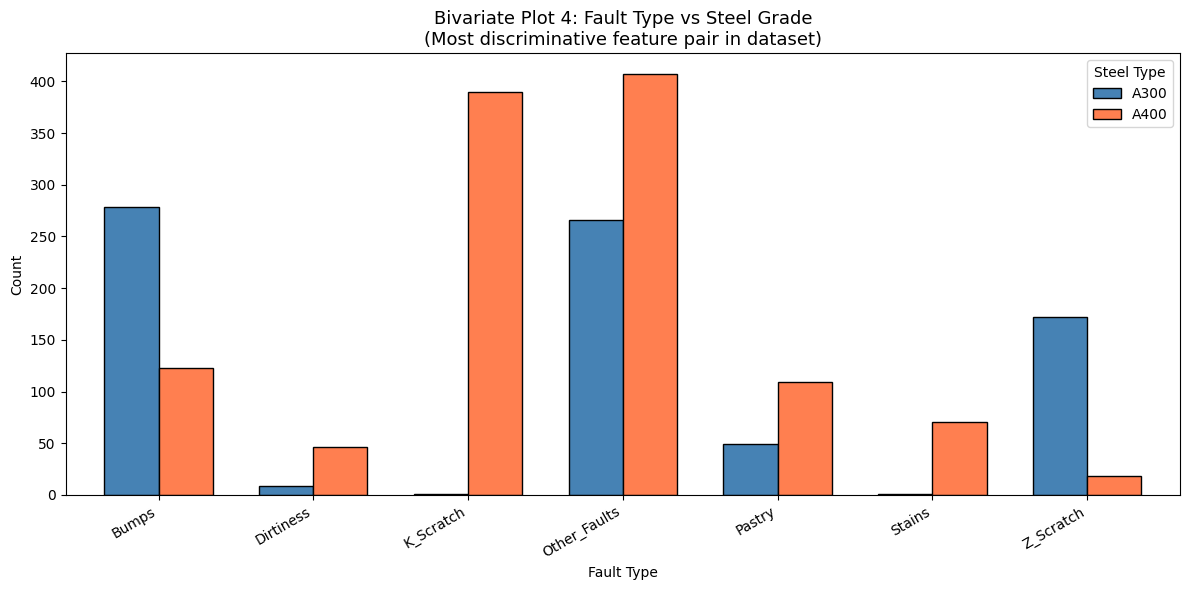


📌 Crosstab (raw counts):
steel_type    A300  A400
fault                   
Bumps          279   123
Dirtiness        9    46
K_Scratch        1   390
Other_Faults   266   407
Pastry          49   109
Stains           1    71
Z_Scratch      172    18


In [20]:
# ----- STEEL TYPE vs FAULT TYPE (Strongest Pattern) -----

import pandas as pd

df_combined = pd.concat([X[['TypeOfSteel_A300', 'TypeOfSteel_A400']], y], axis=1)
df_combined['steel_type'] = df_combined['TypeOfSteel_A300'].map({1: 'A300', 0: 'A400'})
df_combined['fault'] = y.idxmax(axis=1)

crosstab = pd.crosstab(df_combined['fault'], df_combined['steel_type'])

crosstab.plot(kind='bar', figsize=(12, 6), color=['steelblue', 'coral'],
              edgecolor='black', width=0.7)
plt.title('Bivariate Plot 4: Fault Type vs Steel Grade\n(Most discriminative feature pair in dataset)',
          fontsize=13)
plt.xlabel('Fault Type')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Steel Type')
plt.tight_layout()
plt.show()

print("\n📌 Crosstab (raw counts):")
print(crosstab)

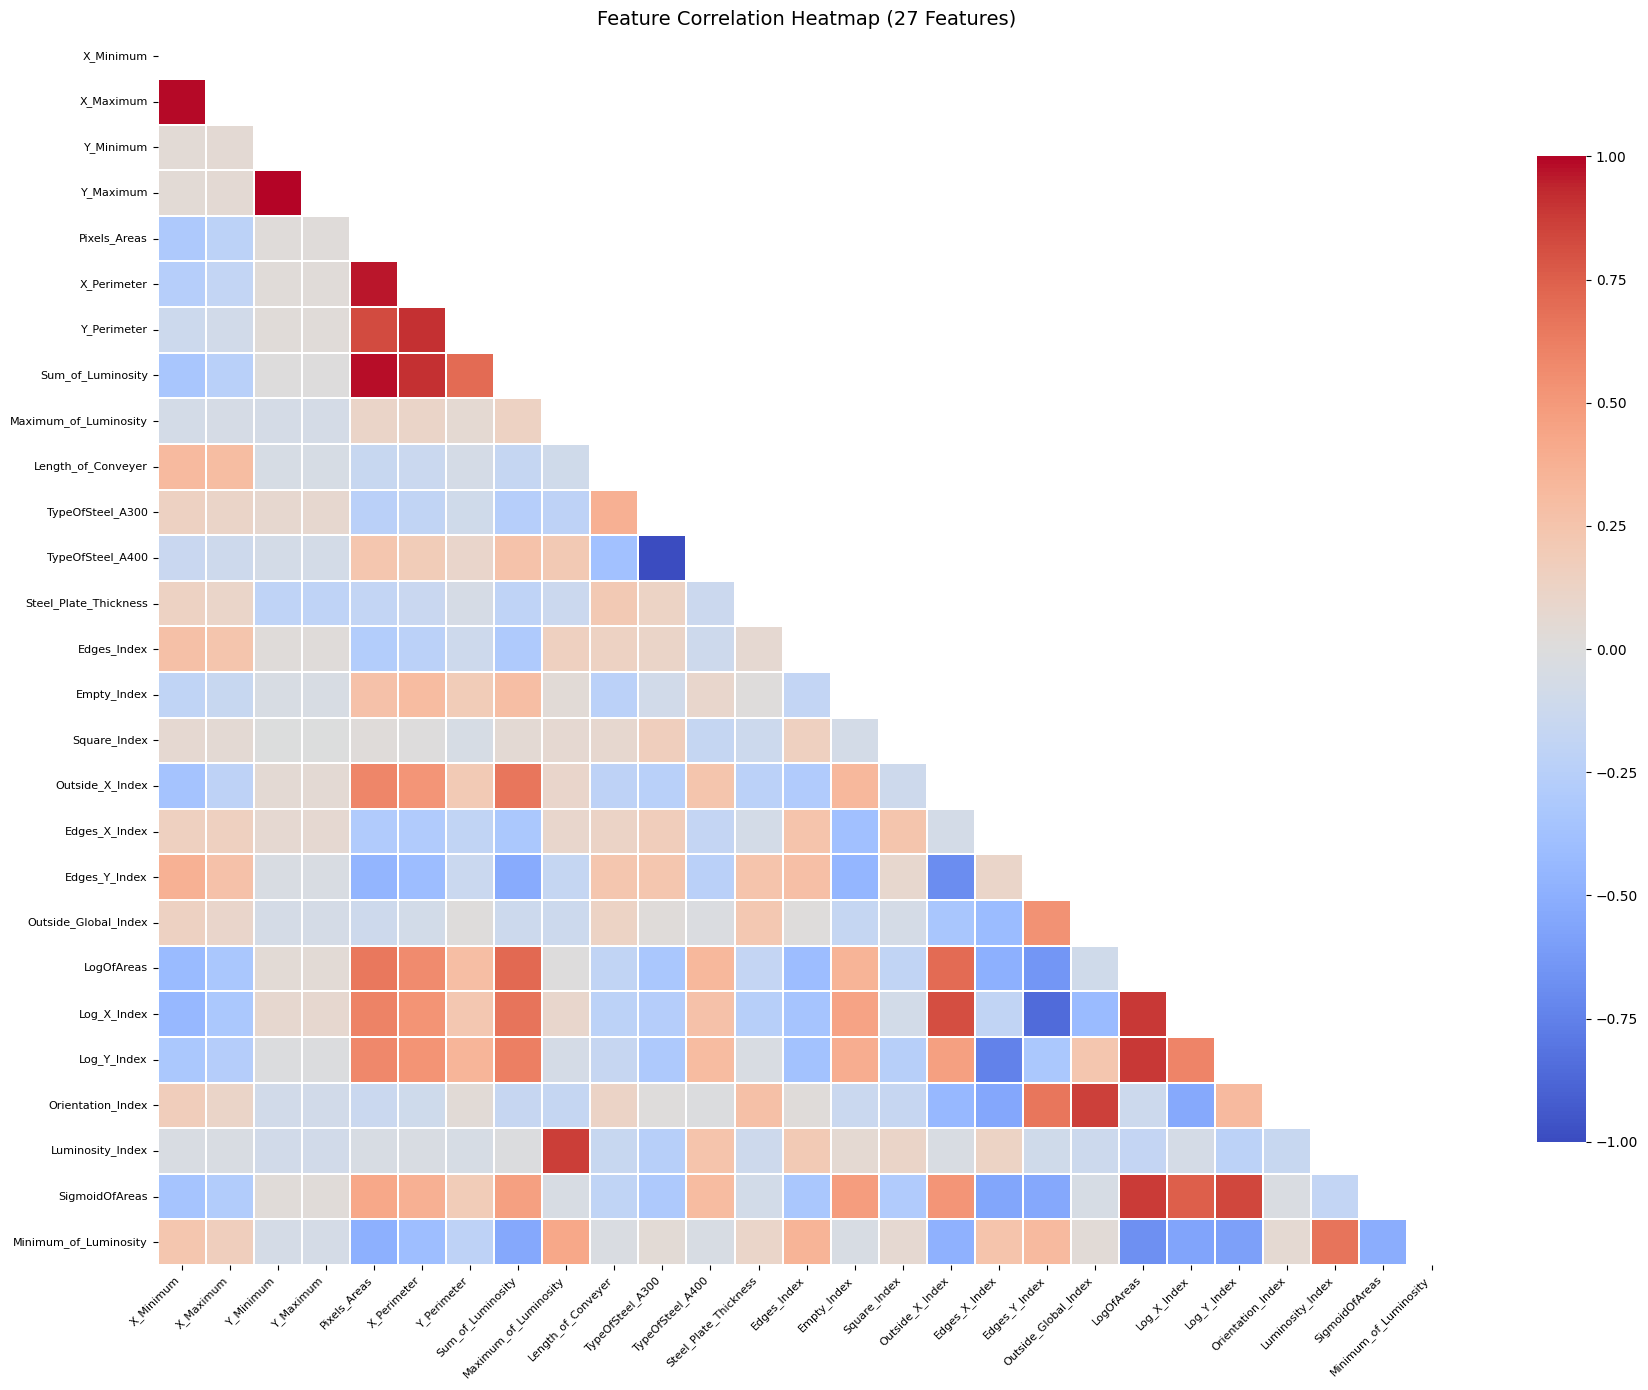


📌 Highly Correlated Feature Pairs (|correlation| > 0.85):
   Y_Maximum ↔ Y_Minimum: 1.0
   TypeOfSteel_A400 ↔ TypeOfSteel_A300: -1.0
   X_Maximum ↔ X_Minimum: 0.988
   Sum_of_Luminosity ↔ Pixels_Areas: 0.979
   X_Perimeter ↔ Pixels_Areas: 0.967
   Sum_of_Luminosity ↔ X_Perimeter: 0.913
   Y_Perimeter ↔ X_Perimeter: 0.912
   Log_X_Index ↔ LogOfAreas: 0.889
   Log_Y_Index ↔ LogOfAreas: 0.883
   SigmoidOfAreas ↔ LogOfAreas: 0.878
   Luminosity_Index ↔ Maximum_of_Luminosity: 0.87
   Orientation_Index ↔ Outside_Global_Index: 0.863
   Log_X_Index ↔ Edges_Y_Index: -0.855


In [16]:
# ----- FEATURE CORRELATION HEATMAP -----
# Business relevance: identifies redundant features before modelling

plt.figure(figsize=(18, 14))

corr_matrix = X.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle

sns.heatmap(corr_matrix,
            mask=mask,
            annot=False,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.3,
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Heatmap (27 Features)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Print highly correlated pairs
print("\n📌 Highly Correlated Feature Pairs (|correlation| > 0.85):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr.append((corr_matrix.columns[i],
                             corr_matrix.columns[j],
                             round(corr_matrix.iloc[i, j], 3)))

for feat1, feat2, corr in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"   {feat1} ↔ {feat2}: {corr}")

In [17]:
print("=== MULTI-LABEL VERIFICATION ===")
plates_per_defect = y.sum(axis=1)
print(plates_per_defect.value_counts().sort_index())
print(f"\nMax defects on one plate: {plates_per_defect.max()}")
print(f"Min defects on one plate: {plates_per_defect.min()}")
print(f"Plates with exactly 1 defect: {(plates_per_defect == 1).sum()}")
print(f"Plates with 0 defects: {(plates_per_defect == 0).sum()}")

=== MULTI-LABEL VERIFICATION ===
1    1941
Name: count, dtype: int64

Max defects on one plate: 1
Min defects on one plate: 1
Plates with exactly 1 defect: 1941
Plates with 0 defects: 0


In [19]:
# ----- CONVERT TO SINGLE-LABEL FORMAT -----

defect_names = ['Pastry', 'Z_Scratch', 'K_Scratch',
                'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

y_single = y.idxmax(axis=1)

print("=== TASK CONFIRMED: MULTI-CLASS (not multi-label) ===")
print(f"Every plate has exactly 1 defect — 7 mutually exclusive classes")
print(f"\nClass distribution:")
print(y_single.value_counts())

=== TASK CONFIRMED: MULTI-CLASS (not multi-label) ===
Every plate has exactly 1 defect — 7 mutually exclusive classes

Class distribution:
Other_Faults    673
Bumps           402
K_Scratch       391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
Name: count, dtype: int64


## EDA Key Findings

### Pattern 1: Luminosity_Index is a Strong Discriminator for Stains
Plot 4 shows that when Stains is the defect present, the Luminosity_Index median
is near **0**, while ALL other defect classes cluster around **-0.15 to -0.20**.
This is the most distinct feature-to-target separation observed.

**Business Significance:** Surface stains alter steel reflectivity in a measurable
way. This means luminosity readings from automated imaging can reliably flag
stain-type defects with high confidence — a strong input for the IDSS decision layer.

---

### Pattern 2: K_Scratch Defects Occupy Significantly Larger Surface Areas
Plot 3 shows K_Scratch as the only defect class where Pixels_Areas is visibly
higher compared to all other defect classes. K_Scratch spans along the rolling
direction, creating elongated damage covering more surface area.

**Business Significance:** Larger defect area = greater material waste. K_Scratch
likely signals a systemic rolling process problem (e.g. worn roller), not a
random point defect. Early detection can trigger maintenance before further plates
are damaged.

---

### Pattern 3: Steel Plate Thickness Strongly Differentiates Defect Types
Plot 5 reveals clear thickness profiles per defect class (verified medians):
- **K_Scratch (40mm) & Stains (50mm):** Occur on the thinnest plates
- **Other_Faults (70mm), Bumps (70mm) & Z_Scratch (70mm):** Mid-range thickness
- **Pastry (85mm) & Dirtiness (100mm):** Occur on the thickest plates

**Business Significance:** Thickness is a strong defect discriminator —
a 2.5x range separates the thinnest (K_Scratch: 40mm) from the thickest
(Dirtiness: 100mm) defect profiles. Thickness-based quality control
checkpoints make sense: thin plates need dedicated monitoring for
K_Scratch and Stains, while thick plates require different inspection
criteria targeting Pastry and Dirtiness defects.

---

### Pattern 4: Defects are Mutually Exclusive — Multi-class Problem
The co-occurrence matrix confirmed **zero plates share two defect types**.
Every one of the 1,941 plates belongs to exactly one defect class.
Despite the dataset's 7 binary column structure, this is a
**multi-class classification** problem with 7 mutually exclusive categories.

**Business Significance:** Each plate failure has a single root cause —
simplifying diagnosis and enabling targeted corrective actions per defect type
rather than combined fault management strategies.

---

### Additional Observations from Histograms & Boxplots
- **Right-skewed features:** Pixels_Areas, X/Y_Perimeter, Sum_of_Luminosity all
  have extreme right skew and outliers → will require log transformation in Phase 2
- **Length_of_Conveyer is multimodal** (peaks at ~1300, ~1400, ~1700) → suggests
  different production batches or conveyor segments worth investigating
- **Luminosity_Index has heavy negative outliers** → edge cases of very dark
  defects that may represent severe surface damage
- **TypeOfSteel_A300 ↔ TypeOfSteel_A400 are perfectly inversely correlated** →
  one column is redundant and should be dropped in Phase 2